Programa para la obtención del eje de giro del sistema con respecto al extremo con diámetro menor de la tobera del montaje experimental que eyecta el fluido de trabajo, el cual se obtiene ajustando los puntos experimentales a una circunferencia mediante un método de mínimos cuadrados, concretamente el ajuste algebraico de Kåsa el cual consiste en:\\

Buscar directamente el centro y el radio de la circunferencia partiendo de la ecuación de un círculo:\\

\begin{equation}
\nonumber
x^2+y^2+Ax+By+C=0
\end{equation}

Para cada punto  $(x_i,y_i), se tiene:\\

\begin{equation}
\nonumber
Ax_i+By_i+C=-(x_i^2+y_i^2)
\end{equation}

Se buscan los valores de A,B Y C que haga mínima la suma de los residuos al cuadrados entre el lados izquierdo y el derecho.



Centro de giro:
xc = -3.390380e+00 +/- 6.770811e-04 cm
yc = -5.997894e-01 +/- 6.542750e-04 cm
Radio = 1.053512e+00 cm
Error xc = 6.770811e-04 cm
Error yc = 6.542750e-04 cm
Incertidumbre común en y (sigma_y) = 3.118271e-02 cm
Error cuadratico medio (MSE) = 9.686597e-04 cm^2
Error cuadratico medio reducido = 9.723616e-04 cm^2
Residuo maximo absoluto = 1.452970e-01 cm
RMSE = 3.112330e-02 cm
MAE = 2.166036e-02 cm
Media de residuos = 2.005084e-03 cm
Desviacion estandar de residuos = 3.107837e-02 cm


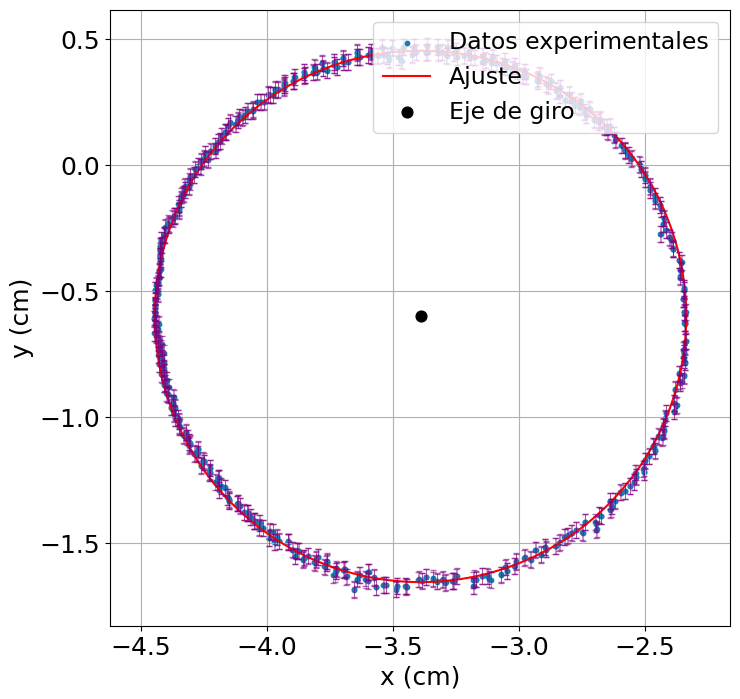

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ====== 1. Leer los datos del archivo de Tracker  ======

##############################################################################
##################INSERTE EL NOMBRE DEL ARCHIVO DE ENTRADA####################
##############################################################################

archivo = "eje_de_giro.txt"  
data = np.loadtxt(archivo, skiprows=1)

x = data[:, 1]
y = data[:, 2]

# ====== 2. Ajuste del círculo (método de Kåsa) ======
# x^2 + y^2 + A x + B y + C = 0

# Construimos la matriz A y el vector b para resolver el sistema de ecuaciones lineales
A_matrix = np.column_stack((x, y, np.ones_like(x))) # junto los vectores como columnas de la matriz A
b_vector = -(x**2 + y**2)

# Resolvemos el sistema A_matrix * params = b_vector para encontrar A, B, C
params, _, _, _ = np.linalg.lstsq(A_matrix, b_vector, rcond=None) 
A, B, C = params

# Estimamos la incertidumbre de los parámetros del ajuste algebraico.
# Esto nos permite propagar el error al centro (xc, yc).
residuos_algebraicos = np.dot(A_matrix, params) - b_vector
varianza_parametros = np.sum(residuos_algebraicos**2) / (len(x) - 3)
covarianza_parametros = varianza_parametros * np.linalg.inv(np.dot(A_matrix.T, A_matrix))

# ====== 3. Centro y radio ======
xc = -A / 2
yc = -B / 2
radio = np.sqrt(xc**2 + yc**2 - C)

# Incertidumbre propagada al centro.
xc_err = 0.5 * np.sqrt(covarianza_parametros[0, 0])
yc_err = 0.5 * np.sqrt(covarianza_parametros[1, 1])

# ====== 3b. Incertidumbre de y con chi^2 reducido = 1 ======
# Ahora no estamos propagando errores del centro, sino estimando la incertidumbre
# de las coordenadas y a partir de los residuos verticales respecto a la circunferencia ajustada.
#
# Para cada x_i tomamos el valor de y de la circunferencia que queda más cerca del dato medido.
# Como una circunferencia puede dar dos valores de y para el mismo x, elegimos la rama más próxima.
y_circ_superior = yc + np.sqrt(np.clip(radio**2 - (x - xc)**2, 0, None))
y_circ_inferior = yc - np.sqrt(np.clip(radio**2 - (x - xc)**2, 0, None))
y_ajuste = np.where(np.abs(y - y_circ_superior) <= np.abs(y - y_circ_inferior), y_circ_superior, y_circ_inferior)

residuos_y = y - y_ajuste
numero_puntos = len(y)
numero_parametros = 3
grados_libertad = numero_puntos - numero_parametros

# Métricas del ajuste:
# - Error cuadrático medio (MSE): media de los residuos al cuadrado.
# - Residuo máximo: máximo valor absoluto del residuo.
error_cuadratico_medio = np.mean(residuos_y**2)
residuo_maximo = np.max(np.abs(residuos_y))

# Estadísticos básicos de los residuos.
res = residuos_y
rmse = np.sqrt(np.mean(res**2))
mae = np.mean(np.abs(res))
mu_res = np.mean(res)
std_res = np.std(res, ddof=1)

# Error cuadrático medio normalizado por los grados de libertad.
# En ajuste estadístico, esta cantidad es la suma de cuadrados reducida:
#   ECM_red = sum(residuos_y^2) / (N - 3)
# y es la magnitud que usamos cuando imponemos chi^2 reducido = 1.
error_cuadratico_medio_reducido = np.sum(residuos_y**2) / grados_libertad

# Imponemos chi^2_red = 1:
#   chi^2_red = sum((residuos_y / sigma_y)^2) / (N - 3) = 1
# Despejando:
#   sigma_y = sqrt( sum(residuos_y^2) / (N - 3) )
sigma_y = np.sqrt(np.sum(residuos_y**2) / grados_libertad)

print("Centro de giro:")
print(f"xc = {xc:.6e} +/- {xc_err:.6e} cm")
print(f"yc = {yc:.6e} +/- {yc_err:.6e} cm")
print(f"Radio = {radio:.6e} cm")
print(f"Error xc = {xc_err:.6e} cm")
print(f"Error yc = {yc_err:.6e} cm")
print(f"Incertidumbre común en y (sigma_y) = {sigma_y:.6e} cm")
print(f"Error cuadratico medio (MSE) = {error_cuadratico_medio:.6e} cm^2")
print(f"Error cuadratico medio reducido = {error_cuadratico_medio_reducido:.6e} cm^2")
print(f"Residuo maximo absoluto = {residuo_maximo:.6e} cm")
print(f"RMSE = {rmse:.6e} cm")
print(f"MAE = {mae:.6e} cm")
print(f"Media de residuos = {mu_res:.6e} cm")
print(f"Desviacion estandar de residuos = {std_res:.6e} cm")


# ====== 4. Generar puntos del círculo ajustado ======
# Generamos un conjunto de puntos alrededor del círculo usando el centro y el radio calculados
theta = np.linspace(0, 2*np.pi, 500) 
x_circ = xc + radio * np.cos(theta)
y_circ = yc + radio * np.sin(theta)

# ====== 5. Gráfica ======
plt.figure(figsize=(8,8))

# Puntos experimentales, se pone scatter para que se vean mejor, con tamaño reducido para coincidir con los ejes
plt.scatter(x, y, s=10, label="Datos experimentales")

# Círculo ajustado
plt.plot(x_circ, y_circ, color="red", label="Ajuste")

# Centro calculado.
plt.scatter(xc, yc, color="black", marker='o', s=60, edgecolors='black', linewidths=1.0, label="Eje de giro")

# Barras de error verticales en los datos de y, usando la incertidumbre común sigma_y
plt.errorbar(x,y,yerr=sigma_y,fmt='none',ecolor='purple',elinewidth=0.5,capsize=2,alpha=0.6,)

plt.xlabel("x (cm)", fontsize=18)
plt.ylabel("y (cm)", fontsize=18)
plt.legend(loc='upper right', fontsize=17)
plt.axis('equal') # Mantener la proporción de los ejes para que el círculo se vea circular
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)


plt.savefig("Ajuste_circular_eje_de_giro.png", dpi=300)
plt.show()